## Get basic information about the dataset

In [1]:
import pandas as pd
import ydata_profiling as yp
candy = pd.read_csv('../data/candy-data.csv')
report = yp.ProfileReport(candy)
report.to_file('../reports/eda_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 769.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

- the report is saved as an HTML file in the specified directory.
- data is pretty clean, no missing values, no major problems detected at first sight
- only issue at the beginning is that the last variable 'winpercent' has a different format then other percent variables (0-100 instead of 0-1), will convert that variable before modeling (to reduced any possible confusion later on)
- relevant correlations:
    - 'fruity' and 'chocolate' (0.714)
    - 'peanutyalmondy' and 'pricepercent' (0.624)
    - 'chocolate' and 'bar' (0.563)
    - 'bar' and 'pluribus' (0.559)
    - 'chocolate' and 'pricepercent' (0.551)

    - 'chocolate' and target 'winpercent' (0.586)
- as we have most of the variables categorical (binary), Pearson correlation is not the best measure, we will calculate also Matthews correlation for categorical variables, which will give us the measure of association between two binary variables. Also, in this case, the sign will indicate the direction of the association.


In [2]:
# calculate matthews correlation for categorical variables
import numpy as np
from sklearn.metrics import matthews_corrcoef
categorical_vars = ['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
                    'crispedricewafer', 'hard', 'bar', 'pluribus']

matthews_corr_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)
for var1 in categorical_vars:
    for var2 in categorical_vars:
        if var1 != var2:
            matthews_corr = matthews_corrcoef(candy[var1], candy[var2])
            matthews_corr_matrix.loc[var1, var2] = matthews_corr
        else:
            matthews_corr_matrix.loc[var1, var2] = 1.0
matthews_corr_matrix = matthews_corr_matrix.astype(float)
matthews_corr_matrix

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus
chocolate,1.000000,-0.741721,0.249875,0.377824,0.254892,0.341210,-0.344177,0.597421,-0.339675
fruity,-0.741721,1.000000,-0.335485,-0.399280,-0.269367,-0.269367,0.390678,-0.515066,0.299725
caramel,0.249875,-0.335485,1.000000,0.059356,0.328493,0.213113,-0.122355,0.333960,-0.269585
peanutyalmondy,0.377824,-0.399280,0.059356,1.000000,0.213113,-0.017646,-0.205557,0.260420,-0.206109
nougat,0.254892,-0.269367,0.328493,0.213113,1.000000,-0.089744,-0.138675,0.522976,-0.310339
crispedricewafer,0.341210,-0.269367,0.213113,-0.017646,-0.089744,1.000000,-0.138675,0.423751,-0.224693
hard,-0.344177,0.390678,-0.122355,-0.205557,-0.138675,-0.138675,1.000000,-0.265165,0.014532
bar,0.597421,-0.515066,0.333960,0.260420,0.522976,0.423751,-0.265165,1.000000,-0.593409
pluribus,-0.339675,0.299725,-0.269585,-0.206109,-0.310339,-0.224693,0.014532,-0.593409,1.000000


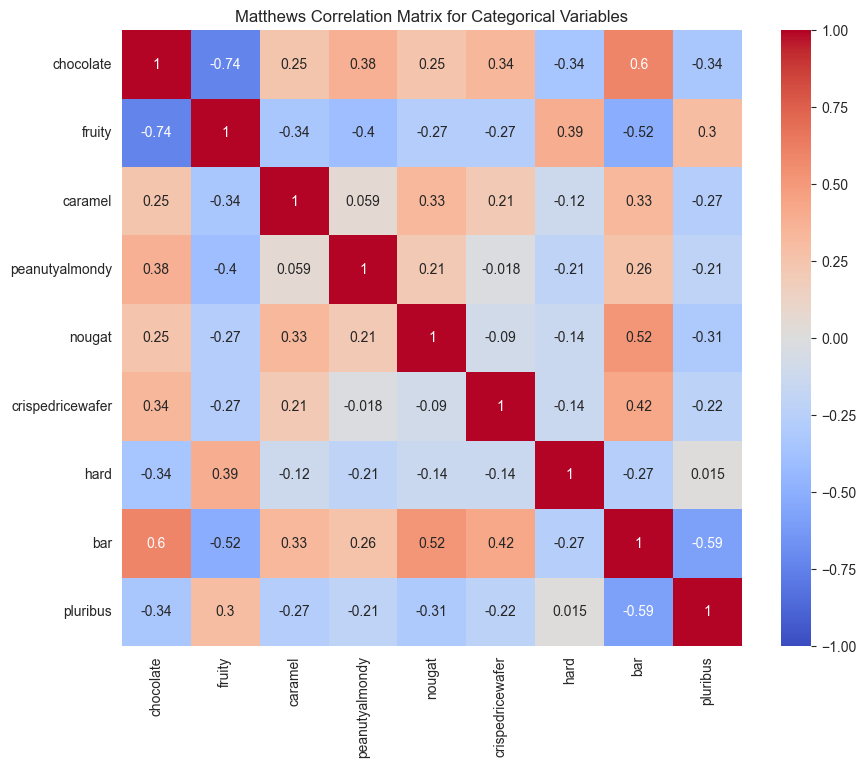

In [3]:
%matplotlib inline
# create a heatmap for matthews correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(matthews_corr_matrix, annot=True, cmap='coolwarm', center
            =0, vmin=-1, vmax=1)
plt.title('Matthews Correlation Matrix for Categorical Variables')
plt.show()

In [5]:
# process the matthews_corr_matrix, sort the individual coefficients and their respective features
matthews_corr_list = []
for var1 in categorical_vars:
    for var2 in categorical_vars:
        if var1 < var2:
            matthews_corr_list.append((var1, var2, matthews_corr_matrix.loc[var1, var2]))
matthews_corr_list.sort(key=lambda x: abs(x[2]), reverse=True)
# create pandas dataframe from the list
matthews_corr_df = pd.DataFrame(matthews_corr_list, columns=['feature 1', 'feature 2', 'matthews_corr'])
matthews_corr_df

,feature 1,feature 2,matthews_corr
0,chocolate,fruity,-0.741721
1,bar,chocolate,0.597421
2,bar,pluribus,-0.593409
3,bar,nougat,0.522976
4,bar,fruity,-0.515066
5,bar,crispedricewafer,0.423751
6,fruity,peanutyalmondy,-0.399280
7,fruity,hard,0.390678
8,chocolate,peanutyalmondy,0.377824
9,chocolate,hard,-0.344177


## Associations Between Binary Candy Variables (Matthews Correlation)

| Variable 1 | Variable 2      | Matthews Correlation | Interpretation                                                                 |
|------------|-----------------|---------------------|-------------------------------------------------------------------------------|
| chocolate  | fruity          | -0.74               | Strong negative correlation: candies are usually either chocolate or fruity    |
| bar        | chocolate       | 0.60                | Moderate positive: chocolate candies are often bars                            |
| bar        | pluribus        | -0.59               | Moderate negative: bars are rarely multi-piece                                 |
| bar        | nougat          | 0.52                | Moderate positive: nougat is common in bars                                    |
| bar        | fruity          | -0.52               | Moderate negative: fruity candies are rarely bars                              |

**Notes:**
- Negative values indicate that the presence of one feature predicts the absence of the other.
- Positive values indicate that the features tend to appear together.
- Matthews correlation is preferred for binary/categorical variables.


Fruity chocolate interaction term might interesting to model as it is a combination which is very improbable. However, there is only one such an occurence in the dataset. So, we will not bother as this will not generalize.


In [9]:
candy['fruity_chocolate'] = candy['chocolate'] * candy['fruity']
candy.loc[candy['fruity_chocolate'] == 1,:]

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,fruity_chocolate
74,Tootsie Pop,1,1,0,0,0,0,1,0,0,0.604,0.325,48.982651,1


In [11]:
candy.loc[candy['chocolate'] == 0 & (candy['fruity'] == 0), :]

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,fruity_chocolate
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086,0
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505,0
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465,0
7,Boston Baked Beans,0,0,0,1,0,0,0,0,1,0.313,0.511,23.417824,0
8,Candy Corn,0,0,0,0,0,0,0,0,1,0.906,0.325,38.010963,0
9,Caramel Apple Pops,0,1,1,0,0,0,0,0,0,0.604,0.325,34.517681,0
11,Chewey Lemonhead Fruit Mix,0,1,0,0,0,0,0,0,1,0.732,0.511,36.017628,0
12,Chiclets,0,1,0,0,0,0,0,0,1,0.046,0.325,24.524988,0
13,Dots,0,1,0,0,0,0,0,0,1,0.732,0.511,42.272076,0
14,Dum Dums,0,1,0,0,0,0,1,0,0,0.732,0.034,39.460556,0


Sort the dataset by winpercent to see the best performing candies. To get a better sense of which candies are the most popular based on winpercent.

In [7]:
candy.sort_values(by='winpercent', ascending=False)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
52,Reese's Peanut Butter cup,1,0,0,1,0,0,0,0,0,0.720,0.651,84.180290
51,Reese's Miniatures,1,0,0,1,0,0,0,0,0,0.034,0.279,81.866257
79,Twix,1,0,1,0,0,1,0,1,0,0.546,0.906,81.642914
28,Kit Kat,1,0,0,0,0,1,0,1,0,0.313,0.511,76.768600
64,Snickers,1,0,1,1,1,0,0,1,0,0.546,0.651,76.673782
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,Jawbusters,0,1,0,0,0,0,1,0,1,0.093,0.511,28.127439
72,Super Bubble,0,1,0,0,0,0,0,0,0,0.162,0.116,27.303865
12,Chiclets,0,1,0,0,0,0,0,0,1,0.046,0.325,24.524988
7,Boston Baked Beans,0,0,0,1,0,0,0,0,1,0.313,0.511,23.417824
